# Esercizio: 3 Visual interattivi per HR
Breve notebook Colab per esplorare `HR_Analytics_Dashboard.xlsx`, calcolare KPI e generare 3 visual (Context → Insight → Action).

Istruzioni rapide:
- Se usi Google Colab: usa la cella di upload o monta Google Drive.
- Se esegui in locale: assicurati che `HR_Analytics_Dashboard.xlsx` sia nella stessa cartella del notebook.

Tempo stimato: 15-25 minuti.

In [7]:
# Install dependencies (Colab: alcune sono già presenti)
%pip install -q pandas openpyxl seaborn matplotlib ipywidgets

# Abilita widget in Colab (se necessario)
try:
    import google.colab
    print('Running on Colab')
except Exception:
    pass


Note: you may need to restart the kernel to use updated packages.


In [8]:
# Caricamento file (Colab)

# Opzione A - Colab: carica il file `HR_Analytics_Dashboard.xlsx` dal tuo computer
try:
    from google.colab import files
    uploaded = files.upload()
    # dopo l'upload il file sarà presente nella working directory
except Exception:
    print('Non sei su Colab o google.colab non è disponibile. Se esegui in locale, assicurati che `HR_Analytics_Dashboard.xlsx` sia nella stessa cartella del notebook.')

# Opzione B - Colab + Drive: monta Drive
# from google.colab import drive
# drive.mount('/content/drive')
# poi usa il path completo: '/content/drive/MyDrive/path/to/HR_Analytics_Dashboard.xlsx'


Non sei su Colab o google.colab non è disponibile. Se esegui in locale, assicurati che `HR_Analytics_Dashboard.xlsx` sia nella stessa cartella del notebook.


In [9]:
# Import librerie e leggere il dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Percorso file: modifica se necessario
excel_path = 'HR_Analytics_Dashboard.xlsx'

# Leggi sheet 'Data'
try:
    df = pd.read_excel(excel_path, sheet_name='Dati_Grezzi', engine='openpyxl')
    display(df.head())
except FileNotFoundError:
    print(f"File {excel_path} non trovato. Controlla il percorso o carica il file.")


c:\Users\edoardo.querio\OneDrive - ITS ICT Piemonte\Desktop\Nuova cartella\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\edoardo.querio\OneDrive - ITS ICT Piemonte\Desktop\Nuova cartella\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


,EmployeeID,Age,Gender,Department,JobRole,MonthlyIncome,OverTime,YearsAtCompany,YearsWithCurrManager,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,Attrition,AttritionNum
0,1001,23,Female,Human Resources,Human Resources,5526,Yes,17,1,4,1,1,Yes,1
1,1002,23,Male,Sales,Manager,6821,No,17,6,2,4,3,No,0
2,1003,49,Female,Sales,Sales Executive,5818,No,3,1,4,1,3,No,0
3,1004,24,Female,Human Resources,Manager,6528,No,12,1,3,3,2,No,0
4,1005,36,Female,Sales,Manager,8936,No,12,4,4,3,2,No,0


In [10]:
# KPI calculations
# AttritionNum: 1 se Attrition == 'Yes'
if 'Attrition' in df.columns:
    df['AttritionNum'] = (df['Attrition'] == 'Yes').astype(int)
else:
    df['AttritionNum'] = 0

overall_attrition = df['AttritionNum'].mean()
avg_income = df['MonthlyIncome'].mean()
avg_age = df['Age'].mean()
percent_overtime = (df['OverTime'] == 'Yes').mean() if 'OverTime' in df.columns else np.nan

kpi_df = pd.DataFrame({
    'KPI': ['Overall Attrition Rate','Average Monthly Income','Average Age','% OverTime'],
    'Value': [overall_attrition, avg_income, avg_age, percent_overtime]
})

# Format and display
kpi_df['ValueFormatted'] = kpi_df.apply(lambda r: f"{r['Value']:.2%}" if 'Rate' in r['KPI'] or '%' in r['KPI'] else (f"{r['Value']:.0f}" if isinstance(r['Value'], (int,float)) else r['Value']), axis=1)
display(kpi_df[['KPI','ValueFormatted']])


,KPI,ValueFormatted
0,Overall Attrition Rate,22.86%
1,Average Monthly Income,6019
2,Average Age,40
3,% OverTime,18.57%


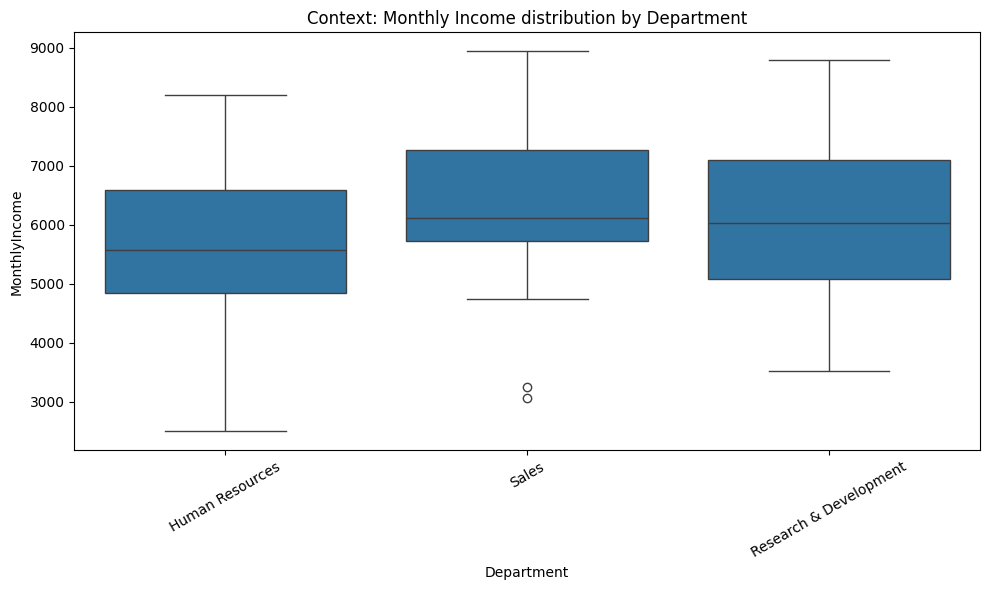

In [11]:
# Visual 1: Context - Boxplot MonthlyIncome by Department
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(x='Department', y='MonthlyIncome', data=df)
plt.title('Context: Monthly Income distribution by Department')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('viz1_income_by_dept.png', dpi=150)
plt.show()


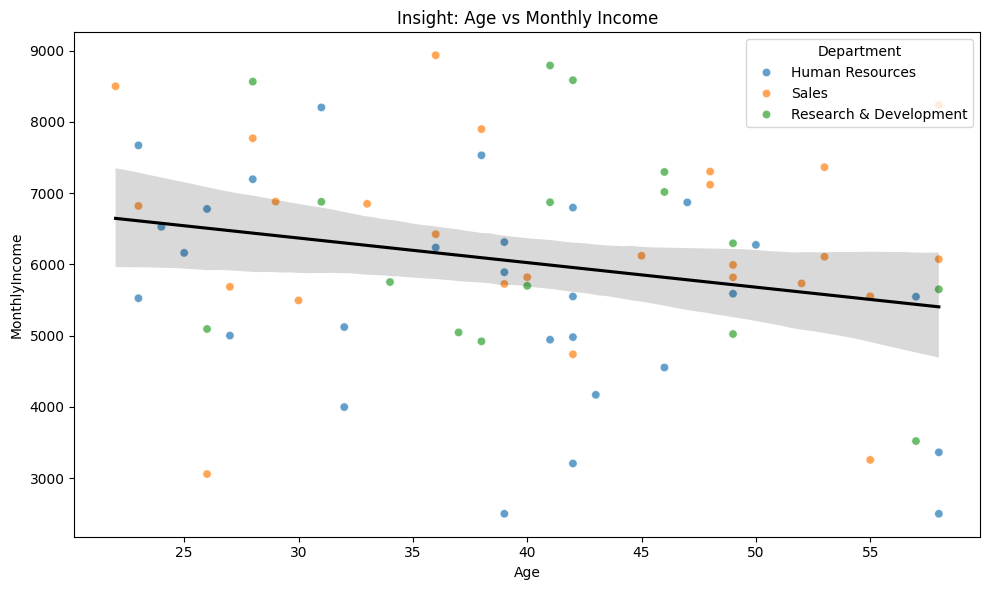

In [12]:
# Visual 2: Insight - Age vs MonthlyIncome scatter with regression
plt.figure(figsize=(10,6))
sns.scatterplot(x='Age', y='MonthlyIncome', hue='Department', data=df, alpha=0.7)
sns.regplot(x='Age', y='MonthlyIncome', data=df, scatter=False, color='black')
plt.title('Insight: Age vs Monthly Income')
plt.tight_layout()
plt.savefig('viz2_age_vs_income.png', dpi=150)
plt.show()


C:\Users\edoardo.querio\AppData\Local\Temp\6\ipykernel_20460\718476436.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TenureBucket', y='AvgIncome', data=income_by_tenure, palette='Blues')


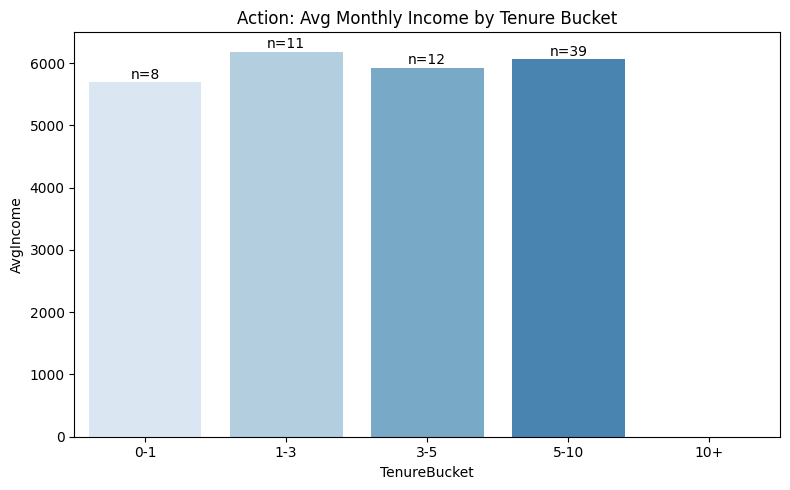

In [13]:
# Visual 3: Action - Avg MonthlyIncome by Tenure Bucket
# Ensure HireDate and TenureYears
if 'HireDate' in df.columns:
    df['HireDate'] = pd.to_datetime(df['HireDate'])
    now = pd.Timestamp.now()
    df['TenureYears'] = (now - df['HireDate']).dt.days / 365.25
else:
    df['TenureYears'] = np.random.uniform(0,10,size=len(df))

bins = [0,1,3,5,10,100]
labels = ['0-1','1-3','3-5','5-10','10+']
df['TenureBucket'] = pd.cut(df['TenureYears'], bins=bins, labels=labels, right=False)

income_by_tenure = df.groupby('TenureBucket').agg(AvgIncome=('MonthlyIncome','mean'), Count=('EmployeeID','count')).reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='TenureBucket', y='AvgIncome', data=income_by_tenure, palette='Blues')
for i, row in income_by_tenure.iterrows():
    plt.text(i, row['AvgIncome'] + 50, f"n={int(row['Count'])}", ha='center')
plt.title('Action: Avg Monthly Income by Tenure Bucket')
plt.tight_layout()
plt.savefig('viz3_income_by_tenure.png', dpi=150)
plt.show()


In [14]:
# Controlli interattivi con ipywidgets
import ipywidgets as widgets
from IPython.display import display, clear_output

# Dropdown per Department
dept_options = ['All'] + sorted(df['Department'].dropna().unique().tolist())
dept_dropdown = widgets.Dropdown(options=dept_options, description='Department:')

# Slider per età minima
age_slider = widgets.IntSlider(value=int(df['Age'].median()), min=int(df['Age'].min()), max=int(df['Age'].max()), description='Min Age:')

# Funzione che aggiorna i grafici
output = widgets.Output()

def update_plots(change=None):
    with output:
        clear_output(wait=True)
        # filtro
        dff = df.copy()
        if dept_dropdown.value != 'All':
            dff = dff[dff['Department'] == dept_dropdown.value]
        dff = dff[dff['Age'] >= age_slider.value]
        
        # plot quick bar: attrition % by department (from filtered data)
        if len(dff) == 0:
            print('Nessun dato per i filtri selezionati')
            return
        fig, ax = plt.subplots(1,2, figsize=(14,5))
        sns.barplot(x=dff['Department'].value_counts().index, y=dff['Department'].value_counts().values, ax=ax[0])
        ax[0].set_title('Count by Department (filtered)')
        sns.scatterplot(x='Age', y='MonthlyIncome', hue='Department', data=dff, ax=ax[1], alpha=0.7)
        plt.tight_layout()
        plt.show()

# Collego i controlli
dept_dropdown.observe(update_plots, names='value')
age_slider.observe(update_plots, names='value')

display(widgets.HBox([dept_dropdown, age_slider]))
display(output)

# Esegui una prima volta
update_plots()


Output()

# Esempi di esplorazione rapido
# 1) Varia il dipartimento dal dropdown per confrontare distribuzioni
# 2) Aumenta il valore di Min Age per vedere come cambia la popolazione filtrata

print('Prova i controlli sopra per analizzare diversi scenari.')

# Summary: Claim & Action

**Claim:** I dipendenti con bassa anzianità mostrano una retribuzione media che non cresce in modo lineare nei primi anni; la crescita più significativa si osserva dopo i 3 anni.

**Action suggerita:** Implementare programmi di onboarding e salary review mirati per i gruppi `0-1` e `1-3` anni; potenziare mentoring e piani di carriera per accelerare la progressione salariale.

**Talking points (1 minuto):**
- Context: distribuzione degli stipendi per dipartimento (visual 1).
- Insight: età non è unico driver dello stipendio; alcuni giovani in ruoli chiave guadagnano già molto (visual 2).
- Action: concentrare programmi di retention e revisione salariale sui neoassunti (visual 3).


In [15]:
# Download generated images (solo in Colab)
try:
    from google.colab import files
    files.download('viz1_income_by_dept.png')
    files.download('viz2_age_vs_income.png')
    files.download('viz3_income_by_tenure.png')
except Exception:
    print('Se non su Colab, scarica i file dalla cartella del notebook o copia i PNG manualmente.')


Se non su Colab, scarica i file dalla cartella del notebook o copia i PNG manualmente.
